In [11]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable,Union,Literal

from skada.datasets import make_shifted_datasets
from skada import source_target_split


Text(0.5, 1.0, 'Target data')

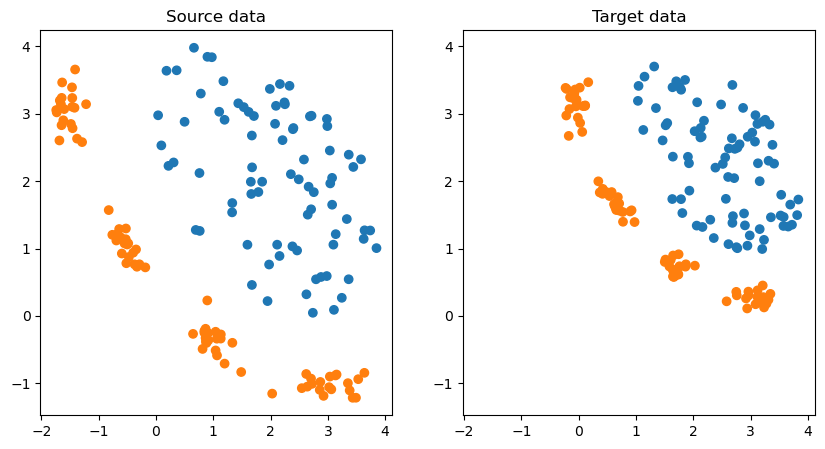

In [12]:
# Get DA dataset
X, y, sample_domain = make_shifted_datasets(
    20, 20, shift="conditional_shift", random_state=42
)

# split source and target for visualization
Xs, Xt, ys, yt = source_target_split(X, y, sample_domain=sample_domain)
sample_domain_s = np.ones(Xs.shape[0])
sample_domain_t = -np.ones(Xt.shape[0]) * 2

# plot data
plt.figure(1, (10, 5))

plt.subplot(1, 2, 1)
plt.scatter(Xs[:, 0], Xs[:, 1], c=ys, cmap="tab10", vmax=9, label="Source")
plt.title("Source data")
ax = plt.axis()

plt.subplot(1, 2, 2)
plt.scatter(Xt[:, 0], Xt[:, 1], c=yt, cmap="tab10", vmax=9, label="Target")
plt.axis(ax)
plt.title("Target data")

In [ ]:
from skada._reweight import BaseReweightAdapter
from sklearn.metrics import pairwise_kernels 

In [ ]:
class KernelLSIF(BaseReweightAdapter): 

    def __init__(self,basis:Union[Callable,Literal["chi2","rbf","laplacian"]]='rbf', constrained=False,njobs=1,max_control_points=None,random_seed=None,**kwds):
        super().__init__()
        self.constrained = constrained
        self.basis = basis
        self.njobs = njobs
        self.max_control_points = max_control_points
        self.random_seed = random_seed
        self.kwds = kwds

    def fit(self,X,y=None,sample_domain=None): 
        Xs, Xt, ys, yt = source_target_split(X, y, sample_domain=sample_domain)
        ns = Xs.shape[0]
        nt = Xt.shape[0]
        n = min(ns,nt)

        # set random seed
        if not self.random_seed is None: 
            rng = np.random.default_rng(seed = self.random_seed)
            mask_id = rng.choice(min(self.max_control_points,nt),replace=False)
            mask = np.full(nt,False)
            mask[mask_id] = True
        else: 
            mask = np.full(nt,True)

        
        # compute 
        H = pairwise_kernels(Xt,Xs)
        h = pairwise_kernels(Xt,None,self.basis,False,self.njobs, **self.kwds)
        hT = np.sum(h,axis=1).reshape(1,-1)



    def _parameter_selection_(self): 
        # trouver kernel_parameters et regularisation
        pass

    def _constrainted_fit(self,X,y=None,sample_domain=None): 
        pass

    def _unconstrained_fit(self,X,y=None,sample_domain=None): 

        self.kernel_parmaters,regularization = self._parameter_selection(...)

        # Get the importance parameter (alpha)
        pass

    def fitted_importance_function():
        return lambda x: np.sum(...) #w function



    def predict(self): 
        pass



#[‘additive_chi2’, ‘chi2’, ‘linear’, ‘poly’, ‘polynomial’, ‘rbf’, ‘laplacian’, ‘sigmoid’, ‘cosine’]


In [ ]:
rng = np.random

In [30]:
np.sum(np.arange(12).reshape(3,4),axis=0)

array([12, 15, 18, 21])